<a href="https://colab.research.google.com/github/YasiruMethmal123/Airline-Delay/blob/main/script/AirlineDelay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Airline Delay
This is a model build to analize and predict the airline delay

In [1]:
import pandas as pd
import numpy as np

In [2]:
#mout to drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
file_path = 'DelayedFlights.csv'
df = pd.read_csv(file_path)
df.head()

,Unnamed: 0,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,0,2008,1,3,4,2003.0,1955,2211.0,2225.0,WN,...,4.0,8.0,0.0,N,0.0,NaN,NaN,NaN,NaN,NaN
1,1,2008,1,3,4,754.0,735,1002.0,1000.0,WN,...,5.0,10.0,0.0,N,0.0,NaN,NaN,NaN,NaN,NaN
2,2,2008,1,3,4,628.0,620,804.0,750.0,WN,...,3.0,17.0,0.0,N,0.0,NaN,NaN,NaN,NaN,NaN
3,4,2008,1,3,4,1829.0,1755,1959.0,1925.0,WN,...,3.0,10.0,0.0,N,0.0,2.0,0.0,0.0,0.0,32.0
4,5,2008,1,3,4,1940.0,1915,2121.0,2110.0,WN,...,4.0,10.0,0.0,N,0.0,NaN,NaN,NaN,NaN,NaN


In [7]:
df.columns

Index(['Unnamed: 0', 'Year', 'Month', 'DayofMonth', 'DayOfWeek', 'DepTime',
       'CRSDepTime', 'ArrTime', 'CRSArrTime', 'UniqueCarrier', 'FlightNum',
       'TailNum', 'ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'ArrDelay',
       'DepDelay', 'Origin', 'Dest', 'Distance', 'TaxiIn', 'TaxiOut',
       'Cancelled', 'CancellationCode', 'Diverted', 'CarrierDelay',
       'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305413 entries, 0 to 305412
Data columns (total 30 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         305413 non-null  int64  
 1   Year               305413 non-null  int64  
 2   Month              305413 non-null  int64  
 3   DayofMonth         305413 non-null  int64  
 4   DayOfWeek          305413 non-null  int64  
 5   DepTime            305413 non-null  float64
 6   CRSDepTime         305413 non-null  int64  
 7   ArrTime            304230 non-null  float64
 8   CRSArrTime         305412 non-null  float64
 9   UniqueCarrier      305412 non-null  object 
 10  FlightNum          305412 non-null  float64
 11  TailNum            305412 non-null  object 
 12  ActualElapsedTime  304229 non-null  float64
 13  CRSElapsedTime     305377 non-null  float64
 14  AirTime            304229 non-null  float64
 15  ArrDelay           304229 non-null  float64
 16  De

In [12]:
df.isna().sum()

,0
Unnamed: 0,0
Year,0
Month,0
DayofMonth,0
DayOfWeek,0
DepTime,0
CRSDepTime,0
ArrTime,1183
CRSArrTime,1
UniqueCarrier,1


# Fixing missing values


In [34]:
df['AirTime'] = df['AirTime'].fillna(df['AirTime'].mean())

In [52]:
df['ArrTime'] = df['ArrTime'].fillna(df['ArrTime'].mean())

In [35]:
df['CRSArrTime'] = df['CRSArrTime'].fillna(df['CRSArrTime'].mean())


In [36]:
df['UniqueCarrier'] = df['UniqueCarrier'].fillna(df['UniqueCarrier'].mode()[0])

In [37]:
df['FlightNum'] = df['FlightNum'].fillna(df['FlightNum'].mode()[0])

In [38]:
df['TailNum'] = df['TailNum'].fillna(df['TailNum'].mode()[0])

In [39]:
df['ActualElapsedTime'] = df['ActualElapsedTime'].fillna(df["ActualElapsedTime"].mean())

In [40]:
df['CRSElapsedTime'] = df['CRSElapsedTime'].fillna(df['CRSElapsedTime'].mean())

In [41]:
df['AirTime'] = df['AirTime'].fillna(df['AirTime'].mean())

In [42]:
df['ArrDelay'] = df['ArrDelay'].fillna(df['ArrDelay'].mean())

In [43]:
df['DepDelay'] = df['DepDelay'].fillna(df['DepDelay'].mean())

In [44]:
df['Origin'] = df ['Origin'].fillna(df['Origin'].mode()[0])

In [56]:
df[['Dest', 'Distance', 'TaxiIn', 'TaxiOut', 'Cancelled','CancellationCode', 'Diverted']] = df[['Dest', 'Distance', 'TaxiIn', 'TaxiOut', 'Cancelled','CancellationCode', 'Diverted']].fillna(df[['Dest', 'Distance', 'TaxiIn', 'TaxiOut', 'Cancelled','CancellationCode', 'Diverted']].mode().iloc[0])

In [46]:
df['CarrierDelay'] = df['CarrierDelay'].fillna(df['CarrierDelay'].mean())

In [47]:
df['WeatherDelay'] = df['WeatherDelay'].fillna(df['WeatherDelay'].mean())

In [48]:
df['NASDelay'] = df['NASDelay'].fillna(df['NASDelay'].mean())

In [49]:
df['SecurityDelay'] = df['SecurityDelay'].fillna(df['SecurityDelay'].mean())

In [50]:
df['LateAircraftDelay'] = df['LateAircraftDelay'].fillna(df['LateAircraftDelay'].mean())

In [57]:
df.isna().sum()

,0
Unnamed: 0,0
Year,0
Month,0
DayofMonth,0
DayOfWeek,0
DepTime,0
CRSDepTime,0
ArrTime,0
CRSArrTime,0
UniqueCarrier,0


In [58]:
df.isna().sum().sum()

np.int64(0)

# Exploatory Data Analysis

analysis of flight delays with respective to factors

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

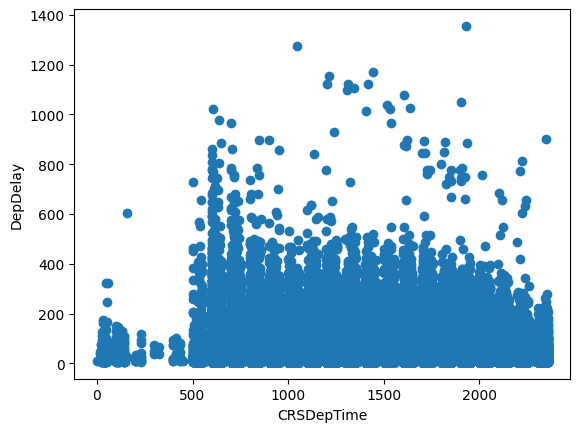

In [60]:
x = df['CRSDepTime']
y = df['DepDelay']
plt.scatter(x,y)
plt.xlabel('CRSDepTime')
plt.ylabel('DepDelay')
plt.show()

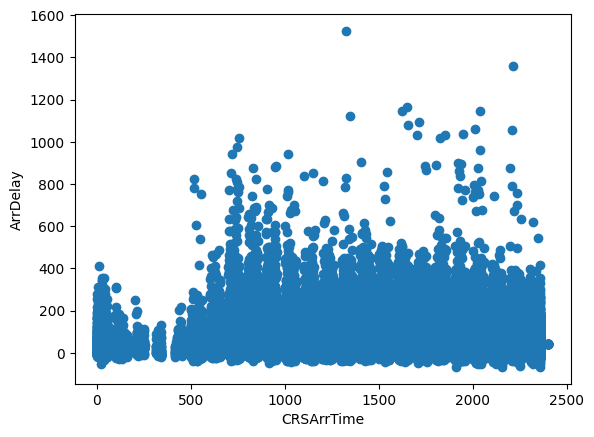

In [61]:
x = df['CRSArrTime']
y = df['ArrDelay']
plt.scatter(x,y)
plt.xlabel('CRSArrTime')
plt.ylabel('ArrDelay')
plt.show()

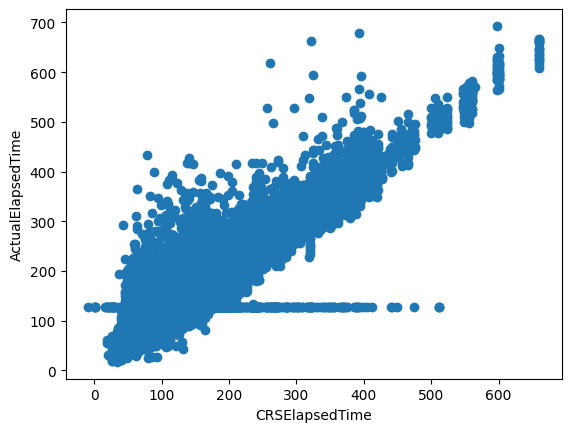

In [63]:
x = df['CRSElapsedTime']
y = df['ActualElapsedTime']
plt.scatter(x,y)
plt.xlabel('CRSElapsedTime')
plt.ylabel('ActualElapsedTime')
plt.show()

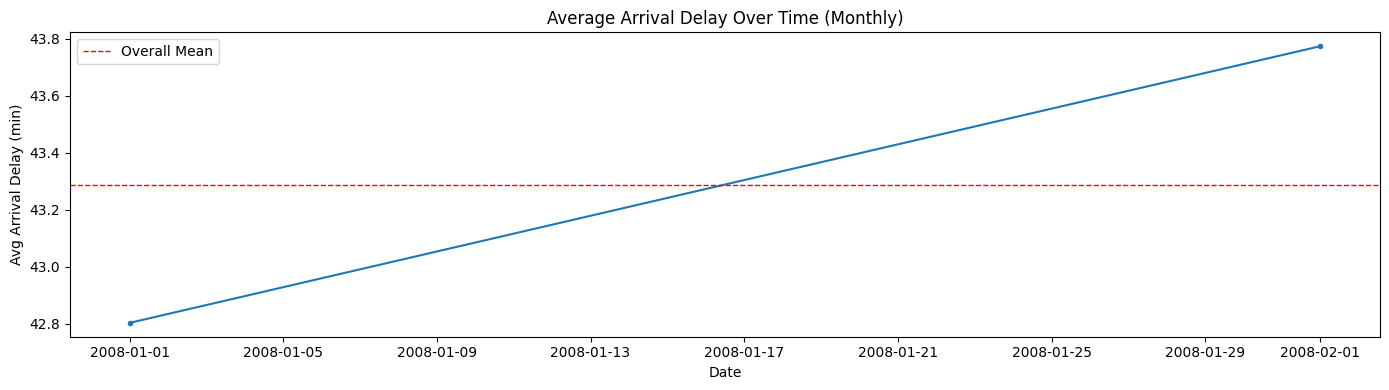

In [66]:
monthly = df.groupby(['Year', 'Month'])['ArrDelay'].mean().reset_index()
monthly['Period'] = pd.to_datetime(monthly[['Year','Month']].assign(Day=1))

plt.figure(figsize=(14, 4))
plt.plot(monthly['Period'], monthly['ArrDelay'], marker='o', linewidth=1.5, markersize=3)
plt.axhline(monthly['ArrDelay'].mean(), color='red', linestyle='--', linewidth=1, label='Overall Mean')
plt.title("Average Arrival Delay Over Time (Monthly)")
plt.xlabel("Date"); plt.ylabel("Avg Arrival Delay (min)")
plt.legend(); plt.tight_layout(); plt.show()

/tmp/ipykernel_4781/3229900271.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=carrier_delay, x='ArrDelay', y='UniqueCarrier', palette='Reds_r')


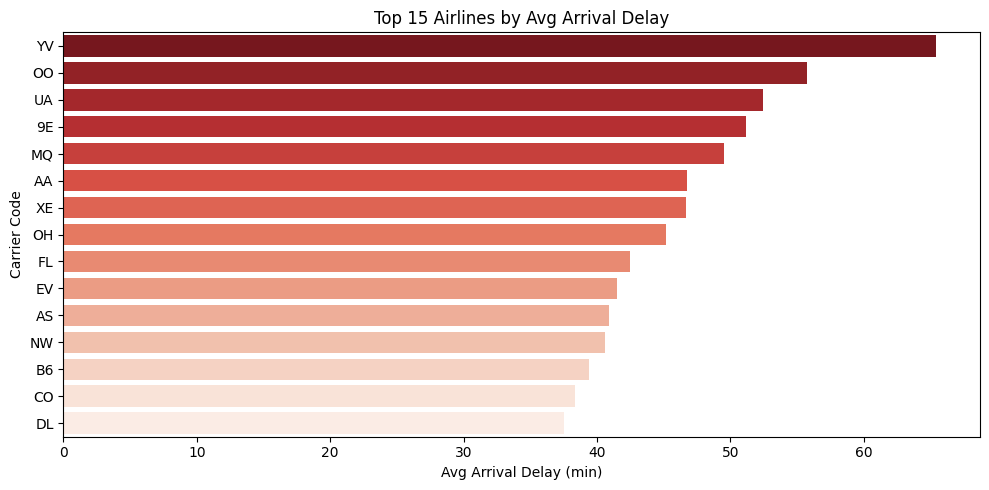

In [67]:
carrier_delay = (df.groupby('UniqueCarrier')['ArrDelay']
                   .mean()
                   .sort_values(ascending=False)
                   .head(15)
                   .reset_index())

plt.figure(figsize=(10, 5))
sns.barplot(data=carrier_delay, x='ArrDelay', y='UniqueCarrier', palette='Reds_r')
plt.title("Top 15 Airlines by Avg Arrival Delay")
plt.xlabel("Avg Arrival Delay (min)"); plt.ylabel("Carrier Code")
plt.tight_layout(); plt.show()

/tmp/ipykernel_4781/3607536295.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=airport_delay, x='ArrDelay', y='Dest', palette='Oranges_r')


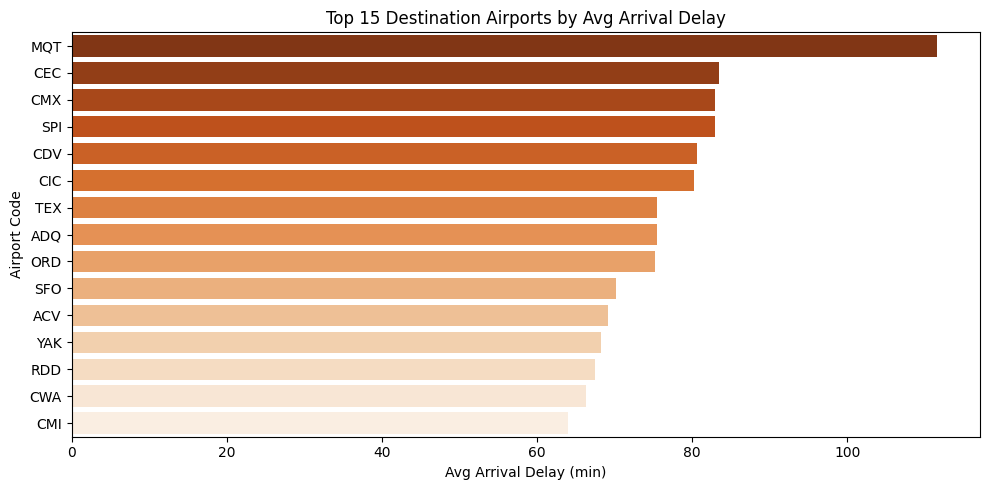

In [68]:
airport_delay = (df.groupby('Dest')['ArrDelay']
                   .mean()
                   .sort_values(ascending=False)
                   .head(15)
                   .reset_index())

plt.figure(figsize=(10, 5))
sns.barplot(data=airport_delay, x='ArrDelay', y='Dest', palette='Oranges_r')
plt.title("Top 15 Destination Airports by Avg Arrival Delay")
plt.xlabel("Avg Arrival Delay (min)"); plt.ylabel("Airport Code")
plt.tight_layout(); plt.show()

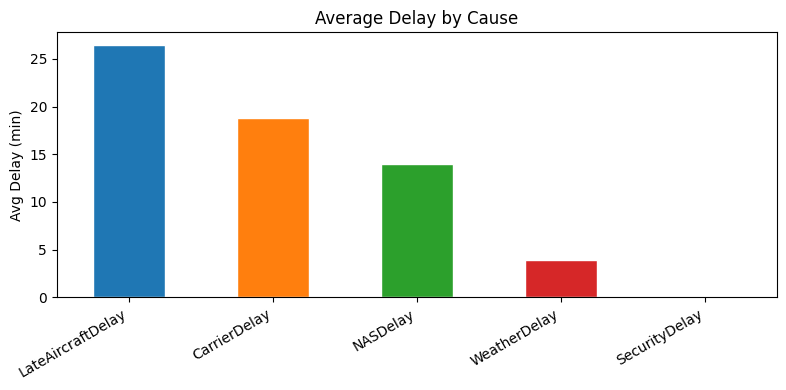

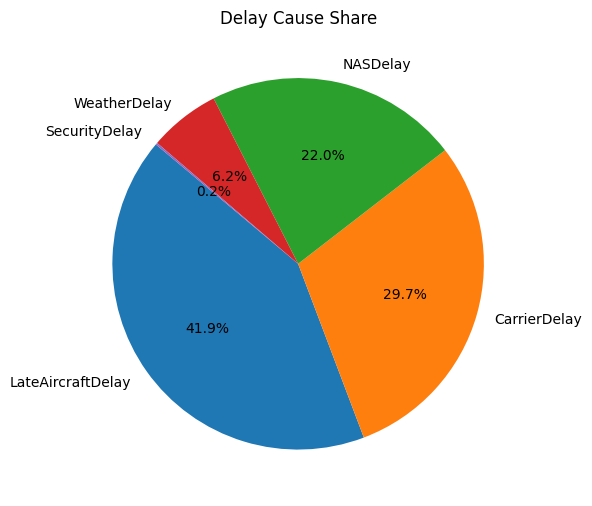

In [69]:
cause_cols = ['CarrierDelay','WeatherDelay','NASDelay','SecurityDelay','LateAircraftDelay']
cause_means = df[cause_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
cause_means.plot(kind='bar', color=sns.color_palette('tab10', len(cause_means)), edgecolor='white')
plt.title("Average Delay by Cause")
plt.ylabel("Avg Delay (min)"); plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

# Proportional pie
plt.figure(figsize=(6, 6))
plt.pie(cause_means, labels=cause_means.index, autopct='%1.1f%%',
        colors=sns.color_palette('tab10', len(cause_means)), startangle=140)
plt.title("Delay Cause Share")
plt.tight_layout(); plt.show()

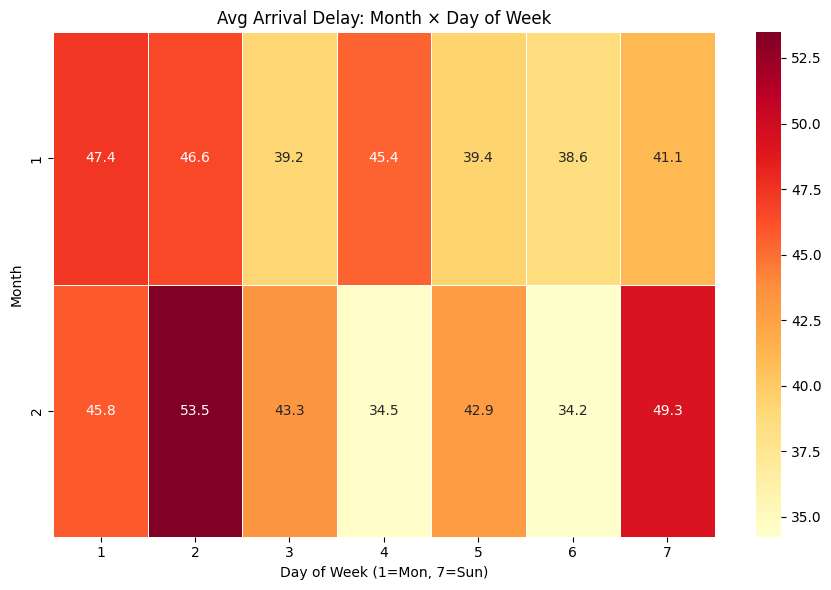

In [70]:
# DayOfWeek: 1=Mon … 7=Sun
pivot = df.pivot_table(values='ArrDelay', index='Month', columns='DayOfWeek', aggfunc='mean')

plt.figure(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap='YlOrRd', linewidths=0.4)
plt.title("Avg Arrival Delay: Month × Day of Week")
plt.xlabel("Day of Week (1=Mon, 7=Sun)")
plt.ylabel("Month"); plt.tight_layout(); plt.show()

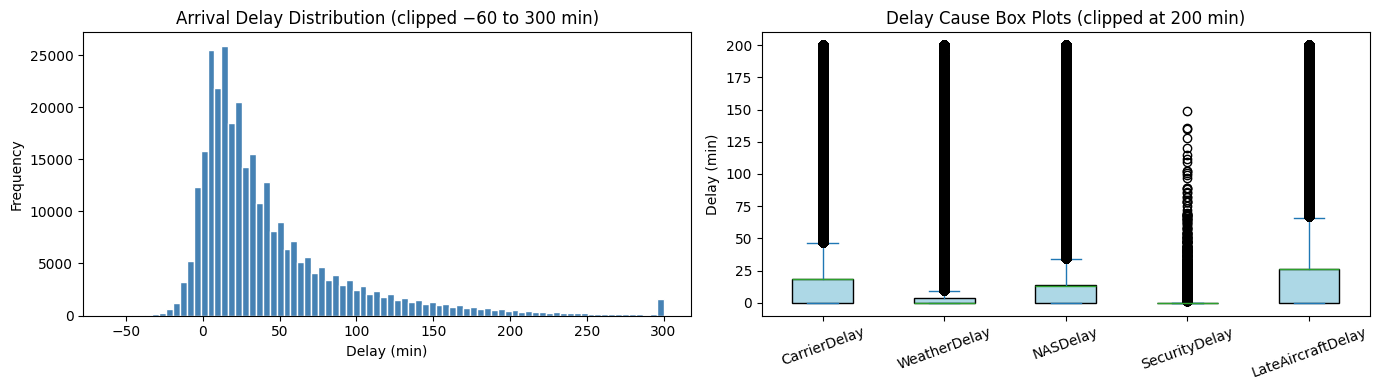

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram (clipped for readability)
clipped = df['ArrDelay'].clip(-60, 300)
axes[0].hist(clipped, bins=80, color='steelblue', edgecolor='white')
axes[0].set_title("Arrival Delay Distribution (clipped −60 to 300 min)")
axes[0].set_xlabel("Delay (min)"); axes[0].set_ylabel("Frequency")

# Box plot per cause
df[cause_cols].clip(upper=200).plot(kind='box', ax=axes[1], patch_artist=True,
    boxprops=dict(facecolor='lightblue'))
axes[1].set_title("Delay Cause Box Plots (clipped at 200 min)")
axes[1].set_ylabel("Delay (min)")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout(); plt.show()

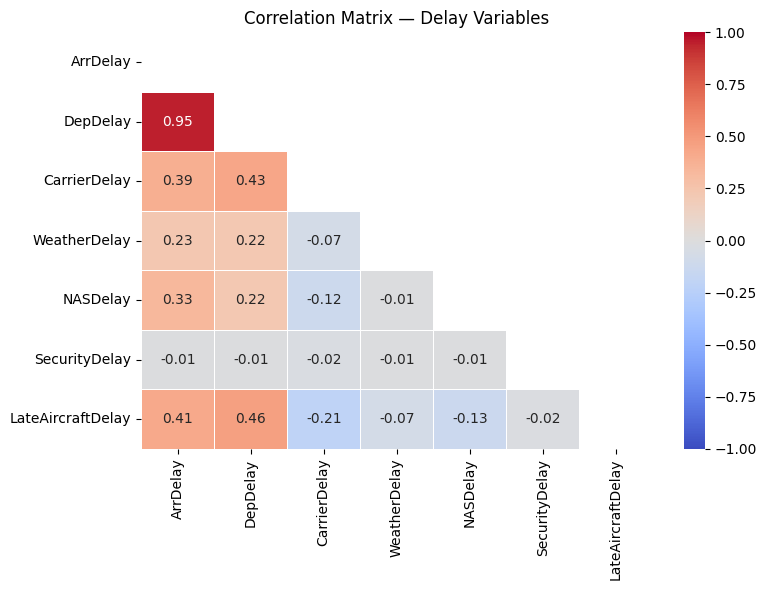

In [72]:
corr_cols = ['ArrDelay','DepDelay'] + cause_cols
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix — Delay Variables")
plt.tight_layout(); plt.show()